# Data Visualization -- Module 2, Class 3

In this notebook you will create 5 types of visualizations from the Superstore dataset:

1. Histogram (distribution of Sales)
2. Boxplot (Profit distribution and outliers)
3. Bar chart (Sales by Category)
4. Correlation heatmap
5. Time series (monthly sales trend)

All 5 are pre-built. At the end, you create 2 additional plots on your own.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

 # In this code, we are importing data.
 # For working with data
 # For mathematical calculations
 # For plotting graphs
 # For plotting nice graphs
 # Background should be white and grid
 # Graph size
 # Font size

In [4]:
# Load dataset (same as data prep lab)
url = "https://raw.githubusercontent.com/bruhitsalex/superstore-dataset/main/Sample%20-%20Superstore.csv"

try:
    df = pd.read_csv(url, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except Exception as e:
    print(f"URL failed ({e}). Upload your CSV manually.")
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head(3)

# In this code, we are uploading data.

URL failed (HTTP Error 404: Not Found). Upload your CSV manually.


Saving archive (1).zip to archive (1).zip
Loaded: 16598 rows, 11 columns


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82


In [18]:
# Quick data prep: convert date columns
# Identify date-like columns and convert
date_cols = [c for c in df.columns if 'date' in c.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Converted {col} to datetime")

# Identify key column names (varies by dataset version)
print(f"\nColumns: {list(df.columns)}")

# In this code, we find the dates and fix them.
# And then, we identify list of columns' names.

Converted Order Date to datetime
Converted Ship Date to datetime

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


---
## 1. Histogram: Distribution of Sales

A histogram shows how values are distributed. Is the data symmetric? Skewed? Are there clusters?

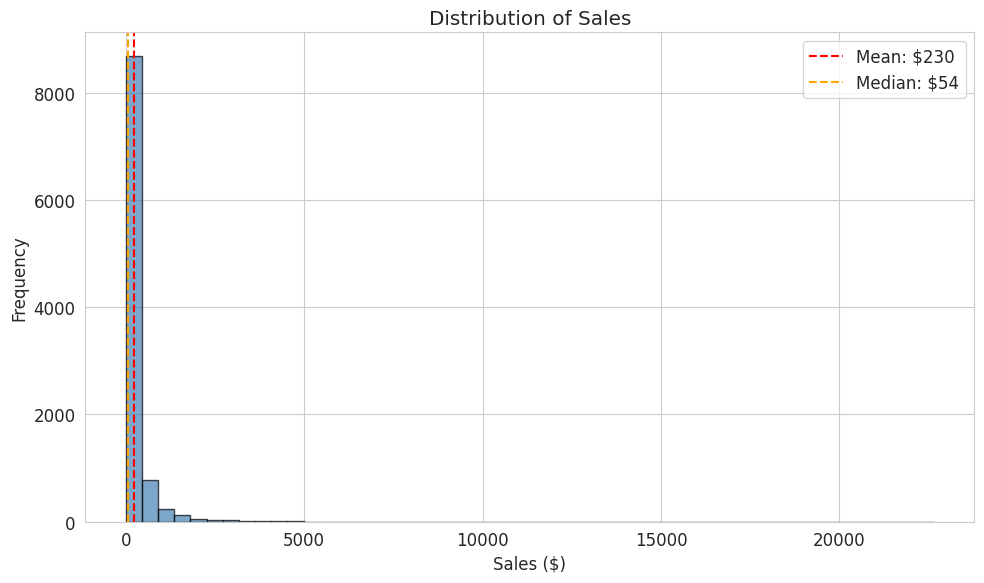

Interpretation: The distribution is right-skewed -- most orders are small,
with a long tail of high-value orders. Mean > Median confirms the skew.


In [19]:
# Find the sales column (may be 'Sales' or 'sales')
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[sales_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Sales')
ax.axvline(df[sales_col].mean(), color='red', linestyle='--', label=f'Mean: ${df[sales_col].mean():,.0f}')
ax.axvline(df[sales_col].median(), color='orange', linestyle='--', label=f'Median: ${df[sales_col].median():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Interpretation: The distribution is right-skewed -- most orders are small,")
print(f"with a long tail of high-value orders. Mean > Median confirms the skew.")

# This code shows the distribution of sales.
# Finds the column named "sales"
# Plots a histogram with 50 bins
# Shows the average (mean) with a red line
# Shows the median with a dark orange line

---
## 2. Boxplot: Profit Distribution

A boxplot shows the quartiles (25th, 50th, 75th percentile) and outliers.

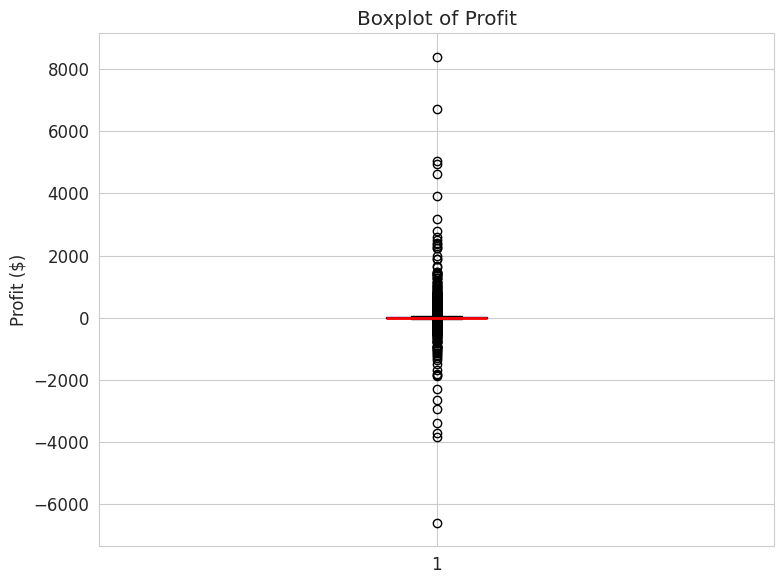

Q1: 1.73 | Q3: 29.36 | IQR: 27.64
Outlier boundaries: [-39.72, 70.82]
Number of outliers: 1881 (18.8% of data)


In [20]:
profit_col = [c for c in df.columns if 'profit' in c.lower()][0]

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(df[profit_col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Profit ($)')
ax.set_title('Boxplot of Profit')
plt.tight_layout()
plt.show()

# Compute IQR for outlier boundaries
Q1 = df[profit_col].quantile(0.25)
Q3 = df[profit_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
n_outliers = ((df[profit_col] < lower_bound) | (df[profit_col] > upper_bound)).sum()

print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")
print(f"Outlier boundaries: [{lower_bound:,.2f}, {upper_bound:,.2f}]")
print(f"Number of outliers: {n_outliers} ({n_outliers/len(df):.1%} of data)")

# Find the column that contains 'profit' (case-insensitive) and get the first match
# Create a figure with size 8x6 inches
# Draw a boxplot of the Profit column
# dropna() removes missing values
# patch_artist=True allows filling the box with color
# boxprops sets the box fill color (lightblue) and border color (navy)
# medianprops sets the median line color (red) and thickness
# Label the y-axis and set the chart title
# Adjust layout so nothing gets cut off
# ---- Outlier Detection using IQR method ----
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
# IQR = the middle 50% range of the data
# Any value below lower_bound or above upper_bound is considered an outlier
# Count how many values fall outside the boundaries (outliers)
# Print the results

---
## 3. Bar Chart: Sales by Category

Compare total sales across product categories.

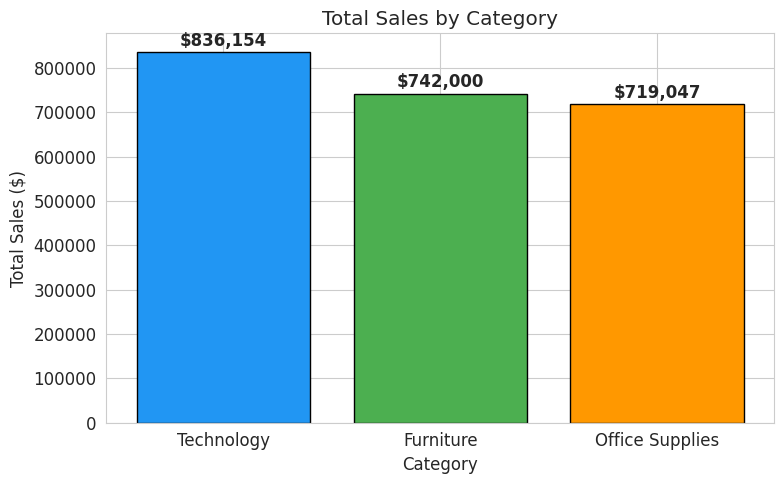

In [21]:
category_col = [c for c in df.columns if 'category' in c.lower()]
# Use the first match (usually 'Category', not 'Sub-Category')
cat_col = category_col[0] if category_col else None

if cat_col:
    cat_sales = df.groupby(cat_col)[sales_col].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(cat_sales.index, cat_sales.values, color=['#2196F3', '#4CAF50', '#FF9800'],
                  edgecolor='black')

    # Add value labels on bars
    for bar, val in zip(bars, cat_sales.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Category')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Total Sales by Category')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Category' column found. Check column names above.")

#In this code, we are looking at sales by category.

---
## 4. Correlation Heatmap

Shows how numerical features relate to each other. Values range from -1 (perfect negative) to +1 (perfect positive).

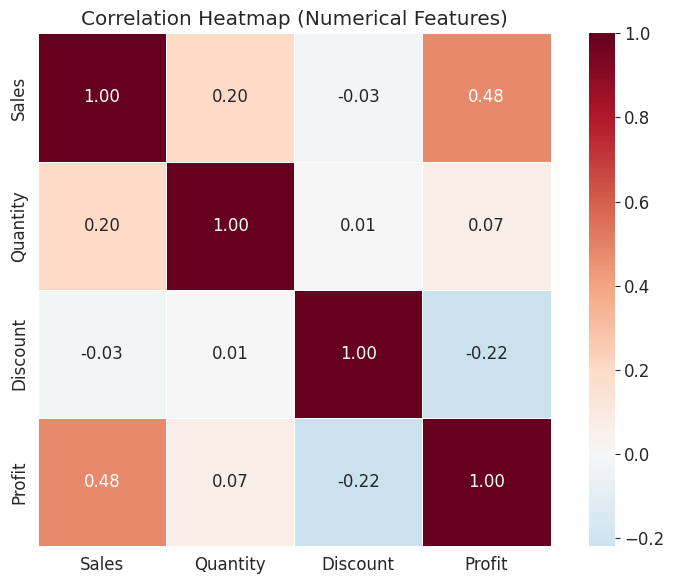

Interpretation:
- Look for strong positive correlations (close to +1): features that move together.
- Look for strong negative correlations (close to -1): features that move opposite.
- Remember: correlation does not imply causation.


In [22]:
# Select numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])

# Drop ID-like columns (Row ID, Postal Code, etc.) that are not meaningful for correlation
id_like = [c for c in num_df.columns if any(kw in c.lower() for kw in ['id', 'postal', 'code', 'zip'])]
num_df = num_df.drop(columns=id_like, errors='ignore')

corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Look for strong positive correlations (close to +1): features that move together.")
print("- Look for strong negative correlations (close to -1): features that move opposite.")
print("- Remember: correlation does not imply causation.")

# In this code, we are plotting the heatmap of the correlation.
# Only takes numeric columns.
# Removes meaningless columns like ID and postal code.
# Calculates the correlation between columns (from -1 to +1).
# Plots the correlation as a colored table.


---
## 5. Time Series: Monthly Sales Trend

Track how total sales change over time. Look for seasonality and trends.

/tmp/ipykernel_8475/1843035289.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()


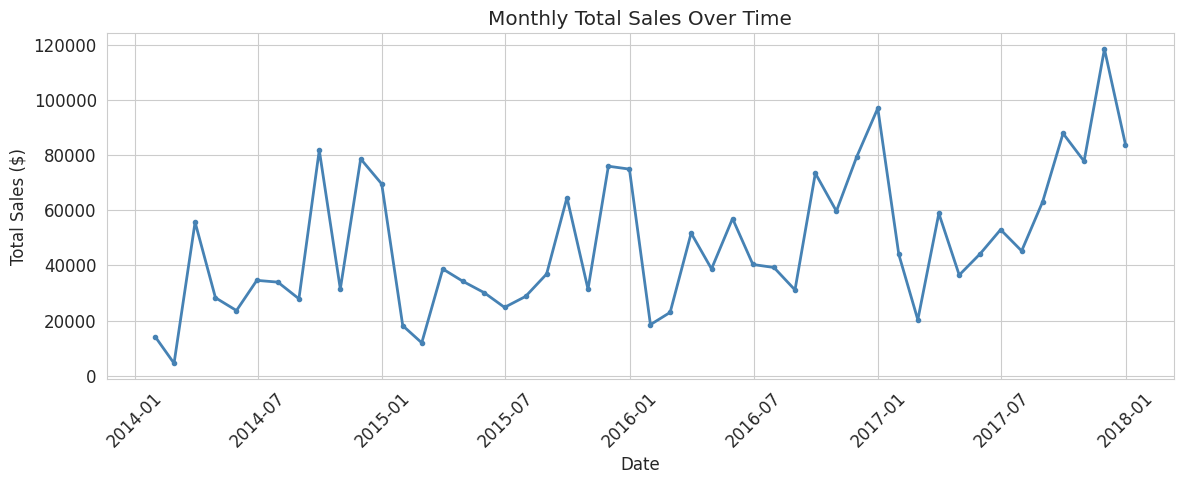

Look for:
- Overall trend (going up, down, or flat?)
- Seasonal patterns (spikes at certain times of year?)
- Anomalies (sudden drops or spikes?)


In [23]:
# Find the order date column
order_date_col = [c for c in df.columns if 'order' in c.lower() and 'date' in c.lower()]

if order_date_col:
    odate = order_date_col[0]

    # Resample to monthly totals
    monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_sales.index, monthly_sales.values, color='steelblue',
            linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Monthly Total Sales Over Time')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    print("Look for:")
    print("- Overall trend (going up, down, or flat?)")
    print("- Seasonal patterns (spikes at certain times of year?)")
    print("- Anomalies (sudden drops or spikes?)")
else:
    print("No order date column found. Check column names.")

# This code is producing a monthly sales line graph for us.
# Groups data month by month and sums up trades.
# 'M' = Monthly
# Draws a line chart along the time axis.

---
## TODO: Create 2 Additional Plots

Create 2 plots that were NOT shown above. Some ideas:
- Scatter plot of Sales vs Profit
- Bar chart of Sales by Region
- Pie chart of order count by Segment (Consumer, Corporate, Home Office)
- Violin plot or histogram of Discount distribution
- Stacked bar chart by Category and Sub-Category

For each plot:
1. Write the code
2. Add title and axis labels
3. Write 2-3 sentences of interpretation in a markdown cell below the plot

In [ ]:
# TODO: Plot 1
# Your code here:


*TODO: Write your interpretation of Plot 1 here.*

In [ ]:
# TODO: Plot 2
# Your code here:


*TODO: Write your interpretation of Plot 2 here.*

---
## Reflection

Answer in a text cell below:

1. The Sales histogram is right-skewed. Why does this happen in retail data? What would it mean if it were perfectly normal?
2. You found outliers in Profit. Should you remove them? What information might you lose?
3. If Discount and Profit have a negative correlation, does that mean the company should stop giving discounts?

Task 2

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/superstore-dataset-final/Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print("Satrlar soni:", df.shape[0])
print("Ustunlar:", df.columns.tolist())
df.head()

Satrlar soni: 9994
Ustunlar: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


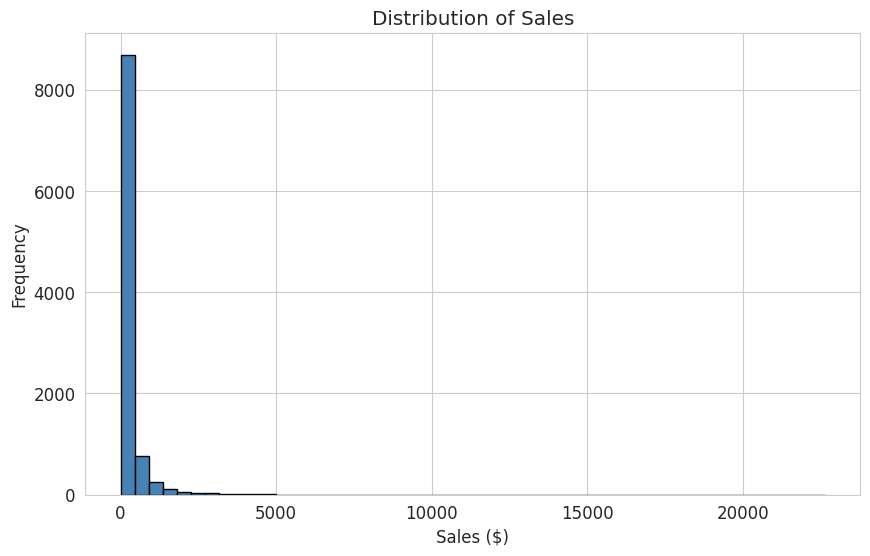

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

"Sales distribution is right-skewed, meaning most orders have low sales values (under $500), while a few orders have very high sales. This is typical in retail data where bulk or luxury purchases are rare."



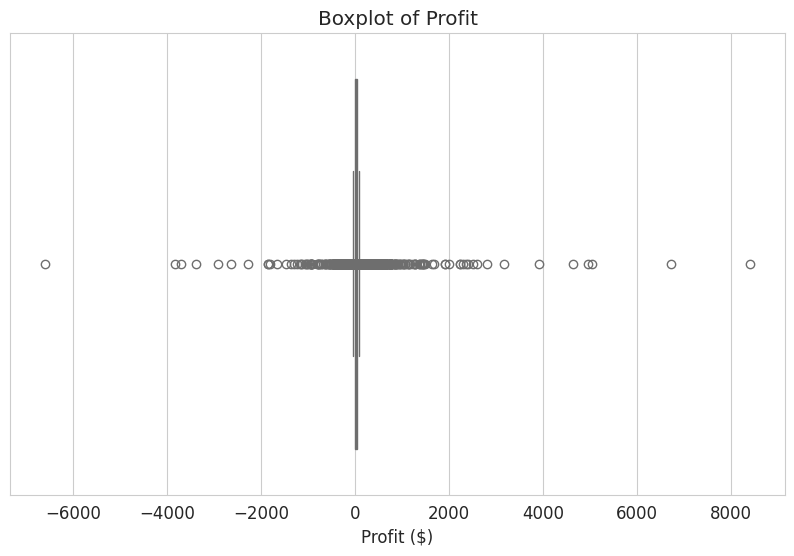

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')
plt.show()


"The Profit boxplot shows that most profits are concentrated between -$50 and $150. There are many visible outliers on both sides, meaning some orders have very high profits and some have big losses."

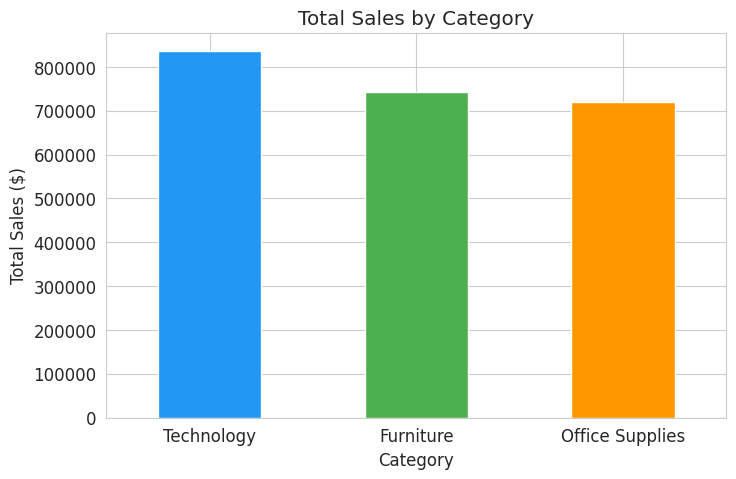

In [35]:
# Kategoriya bo'yicha savdo
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

"Technology category generates the most revenue, followed by Furniture and Office Supplies. This suggests that high-value tech products drive the majority of store sales."

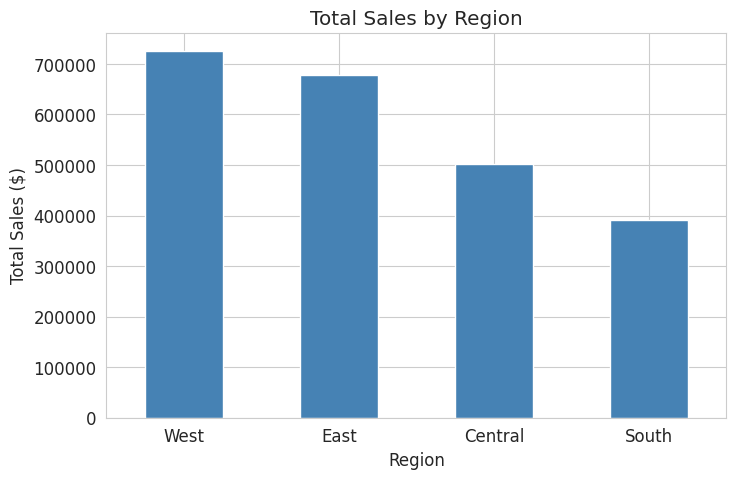

In [36]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

"The West region generates the most sales, followed by East, Central, and South. This could be due to higher population density and more stores in the West region."

In [37]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*100:.1f}%)")

Q1: 1.73, Q3: 29.36, IQR: 27.64
Lower bound: -39.72, Upper bound: 70.82
Number of outliers: 1881 out of 9994 rows (18.8%)


"Using the IQR method, we found 1881 outliers out of 9994 rows (18.8%). The outliers include both very high-profit orders and big-loss orders. This means some products are either extremely profitable or sold at a significant loss, possibly due to heavy discounting."

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


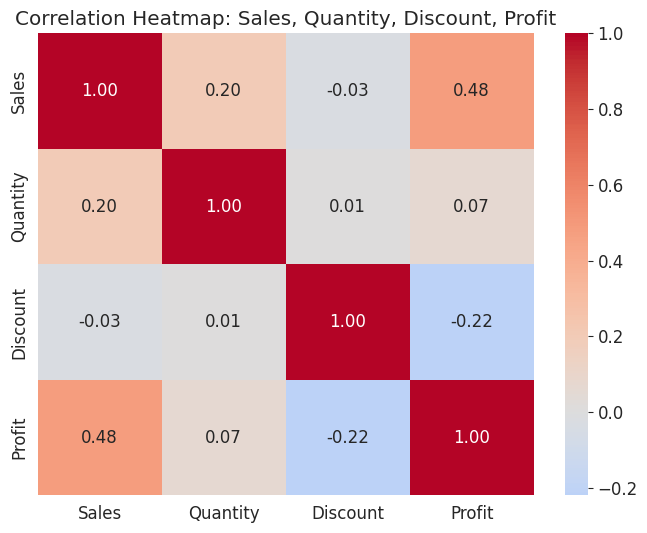

In [38]:
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numerical_cols.corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.show()


"Sales and Profit have the strongest positive correlation. Discount and Profit have a negative correlation, meaning higher discounts lead to lower profits. This suggests the company should be careful about giving large discounts."



/tmp/ipykernel_14340/997669888.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


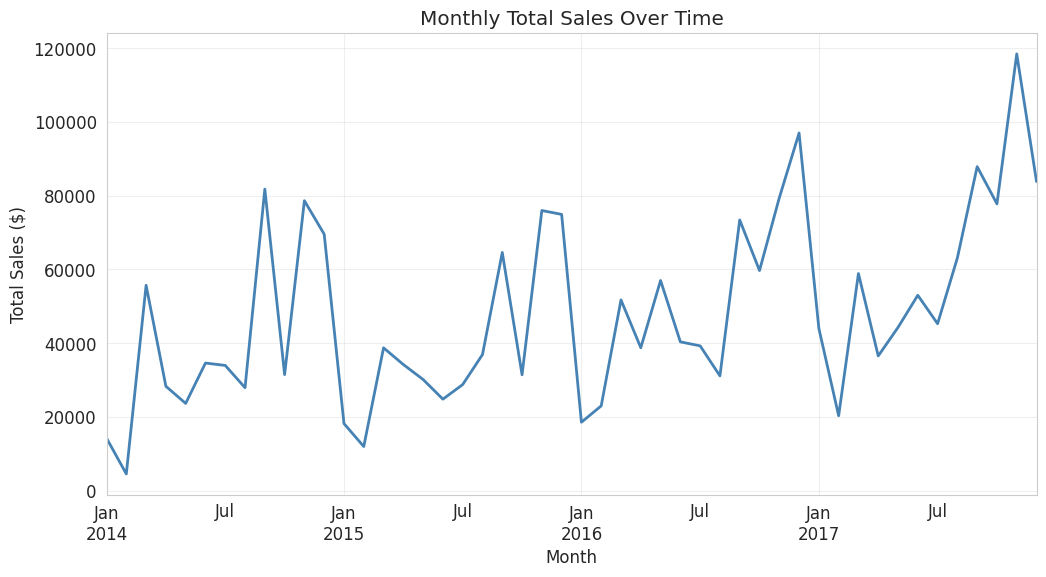

In [39]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()


"Monthly sales show an upward trend over time, with noticeable spikes at the end of each year (November-December), likely due to holiday shopping. There are some dips in the middle of the year, particularly in February and April."

"Sales data is right-skewed because most customers make small purchases. Only a few customers buy expensive items like high-end technology products, creating a long tail on the right side."

"We should not remove outliers because they represent real business events. Removing them would cause us to lose important information about our best and worst performing products."

"No, the company should not stop giving discounts entirely. The negative correlation shows discounts reduce profit, but discounts may also attract more customers. The company should find the optimal discount level."

"As a store manager, I would increase inventory and staff during November-December to prepare for the holiday sales spike. I would also run promotions during slow months like February to boost sales."

